## Import Data

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [58]:
data = pd.read_csv(r"D:\Downloads\Udemy-PY\Spotify_Youtube Dataset.csv")

In [59]:
data.head()

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08


In [60]:
data.columns

Index(['Unnamed: 0', 'Artist', 'Url_spotify', 'Track', 'Album', 'Album_type',
       'Uri', 'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness',
       'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo',
       'Duration_ms', 'Url_youtube', 'Title', 'Channel', 'Views', 'Likes',
       'Comments', 'Description', 'Licensed', 'official_video', 'Stream'],
      dtype='object')

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20718 entries, 0 to 20717
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        20718 non-null  int64  
 1   Artist            20718 non-null  object 
 2   Url_spotify       20718 non-null  object 
 3   Track             20718 non-null  object 
 4   Album             20718 non-null  object 
 5   Album_type        20718 non-null  object 
 6   Uri               20718 non-null  object 
 7   Danceability      20716 non-null  float64
 8   Energy            20716 non-null  float64
 9   Key               20716 non-null  float64
 10  Loudness          20716 non-null  float64
 11  Speechiness       20716 non-null  float64
 12  Acousticness      20716 non-null  float64
 13  Instrumentalness  20716 non-null  float64
 14  Liveness          20716 non-null  float64
 15  Valence           20716 non-null  float64
 16  Tempo             20716 non-null  float6

In [62]:
data.drop(columns = ['Unnamed: 0','Uri','Url_spotify','Url_youtube'], inplace = True)

In [63]:
data.isna().sum()

Artist                0
Track                 0
Album                 0
Album_type            0
Danceability          2
Energy                2
Key                   2
Loudness              2
Speechiness           2
Acousticness          2
Instrumentalness      2
Liveness              2
Valence               2
Tempo                 2
Duration_ms           2
Title               470
Channel             470
Views               470
Likes               541
Comments            569
Description         876
Licensed            470
official_video      470
Stream              576
dtype: int64

In [64]:
data['Likes'] = data['Likes'].fillna(0)
data['Comments'] = data['Comments'].fillna(0)

In [65]:
data.dropna(inplace = True) # Removed all missing values

### 1. Show top 10 Artists with highest views from YouTube

In [66]:
Artists_grouped = data.groupby('Artist')['Views'].sum()
Artists_grouped

Artist
$NOT              1.107849e+08
$uicideboy$       3.317202e+08
(G)I-DLE          1.754954e+09
*NSYNC            1.027833e+09
070 Shake         9.609936e+07
                      ...     
will.i.am         2.830801e+09
Ángela Aguilar    1.385295e+09
Ñejo              6.266808e+08
Ñengo Flow        8.127263e+08
Øneheart          3.462331e+07
Name: Views, Length: 2040, dtype: float64

In [67]:
Artists_grouped.sort_values(ascending = False).head(10)

Artist
Ed Sheeran                 1.546021e+10
CoComelon                  1.460167e+10
Katy Perry                 1.312063e+10
Charlie Puth               1.216759e+10
Luis Fonsi                 1.162811e+10
Justin Bieber              1.099079e+10
Daddy Yankee               1.086828e+10
Bruno Mars                 1.023184e+10
Macklemore & Ryan Lewis    1.012206e+10
Coldplay                   9.997278e+09
Name: Views, dtype: float64

### 2. Top 10 Tracks with highest stream on Spotify

In [68]:
data.head(2)

,Artist,Track,Album,Album_type,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,...,Duration_ms,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,6.0,-6.679,0.1770,0.00836,...,222640.0,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,8.0,-5.815,0.0302,0.08690,...,200173.0,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08


In [69]:
Track_streams = data.groupby('Track')['Stream'].sum()
Track_streams

Track
!ly (feat. Coez)                52628204.0
#1 - Colby O'Donis Remix          561794.0
#3                              45002482.0
#41                             34528391.0
#Ysya2020 Vol. 5 - Silbando     26297019.0
                                  ...     
高嶺の花子さん                         69373615.0
그대라는 시                          84972553.0
눈,코,입 (Eyes, Nose, Lips)       112300290.0
러시안 룰렛 Russian Roulette        151307068.0
링가링가 (RINGA LINGA)              36450721.0
Name: Stream, Length: 16662, dtype: float64

In [70]:
Track_streams.sort_values(ascending = False).head(10)

Track
Closer                                                         5.465365e+09
Can't Hold Us (feat. Ray Dalton)                               5.225629e+09
Sunflower - Spider-Man: Into the Spider-Verse                  5.076660e+09
Happier                                                        4.757615e+09
STAY (with Justin Bieber)                                      4.731555e+09
Señorita                                                       4.672440e+09
The Middle                                                     4.566883e+09
Eastside (with Halsey & Khalid)                                4.274888e+09
lovely (with Khalid)                                           4.221148e+09
Enemy (with JID) - from the series Arcane League of Legends    4.182328e+09
Name: Stream, dtype: float64

In [71]:
x = data[['Track', 'Stream']]           # By different way
x

,Track,Stream
0,Feel Good Inc.,1.040235e+09
1,Rhinestone Eyes,3.100837e+08
2,New Gold (feat. Tame Impala and Bootie Brown),6.306347e+07
3,On Melancholy Hill,4.346636e+08
4,Clint Eastwood,6.172597e+08
...,...,...
20713,JUST DANCE HARDSTYLE,9.227144e+06
20714,SET FIRE TO THE RAIN HARDSTYLE,1.089818e+07
20715,OUTSIDE HARDSTYLE SPED UP,6.226110e+06
20716,ONLY GIRL HARDSTYLE,6.873961e+06


In [72]:
x.sort_values(by = 'Stream', ascending = False ).head(10)

,Track,Stream
15250,Blinding Lights,3.386520e+09
12452,Shape of You,3.362005e+09
19186,Someone You Loved,2.634013e+09
17937,rockstar (feat. 21 Savage),2.594927e+09
17445,Sunflower - Spider-Man: Into the Spider-Verse,2.538330e+09
17938,Sunflower - Spider-Man: Into the Spider-Verse,2.538330e+09
13503,One Dance,2.522432e+09
16099,Closer,2.456205e+09
16028,Closer,2.456205e+09
14030,Believer,2.369272e+09


### 3. What are the most common Album on Spotify?

In [73]:
data['Album_type'].unique()

array(['album', 'single', 'compilation'], dtype=object)

In [74]:
c = data['Album_type'].value_counts()
c


Album_type
album          13952
single          4653
compilation      693
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

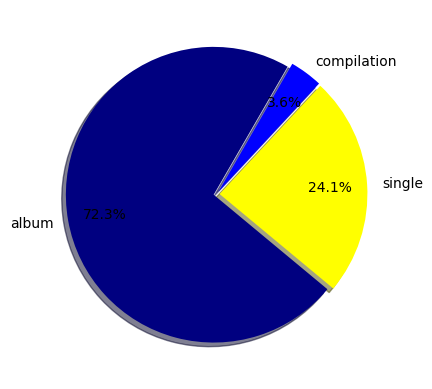

In [75]:
plt.pie(c, labels = c.index, autopct = "%1.1f%%", startangle = 60, colors = ['navy','yellow','blue'], shadow = True, explode = (0.02,0.02,0.02), pctdistance = 0.75 )
plt.show

### 4. How do different Comments, Likes and Views are compared between different Album types?

In [76]:
df = data.groupby('Album_type')[['Views','Likes','Comments']].mean()
df

,Views,Likes,Comments
Album_type,,,
album,1.014359e+08,672593.609948,29032.951548
compilation,8.500535e+07,544275.818182,18074.903319
single,8.480843e+07,722266.303890,27313.048571


In [77]:
df = df.reset_index()
df

,Album_type,Views,Likes,Comments
0,album,1.014359e+08,672593.609948,29032.951548
1,compilation,8.500535e+07,544275.818182,18074.903319
2,single,8.480843e+07,722266.303890,27313.048571


In [78]:
df_reshape = pd.melt(df, id_vars = 'Album_type', var_name = 'Attribute', value_name = 'Total')
df_reshape

,Album_type,Attribute,Total
0,album,Views,1.014359e+08
1,compilation,Views,8.500535e+07
2,single,Views,8.480843e+07
3,album,Likes,6.725936e+05
4,compilation,Likes,5.442758e+05
5,single,Likes,7.222663e+05
6,album,Comments,2.903295e+04
7,compilation,Comments,1.807490e+04
8,single,Comments,2.731305e+04


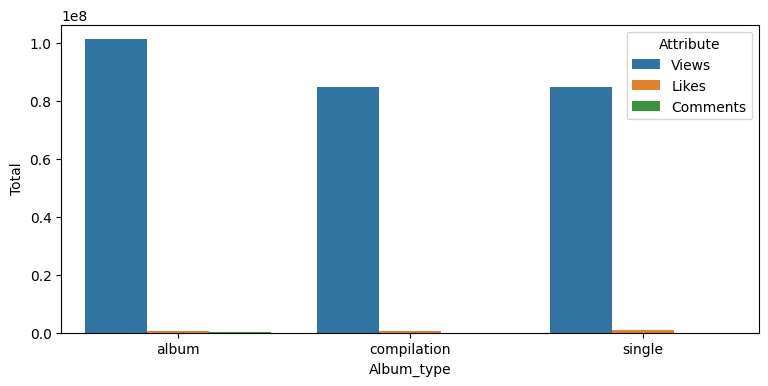

In [79]:
plt.figure(figsize=(9,4))
sns.barplot(x = 'Album_type', y = 'Total',hue = 'Attribute', data = df_reshape 
           );

### 5. Show top 5 Youtube channels on the base of Views

In [83]:
yt_views = data.groupby('Channel')['Views'].sum().sort_values(ascending = False).head(5)
yt_views

Channel
T-Series            4.796159e+10
LuisFonsiVEVO       2.170252e+10
CalvinHarrisVEVO    1.828114e+10
Macklemore          1.700341e+10
Ed Sheeran          1.691822e+10
Name: Views, dtype: float64

In [92]:
yt_views = yt_views.reset_index()

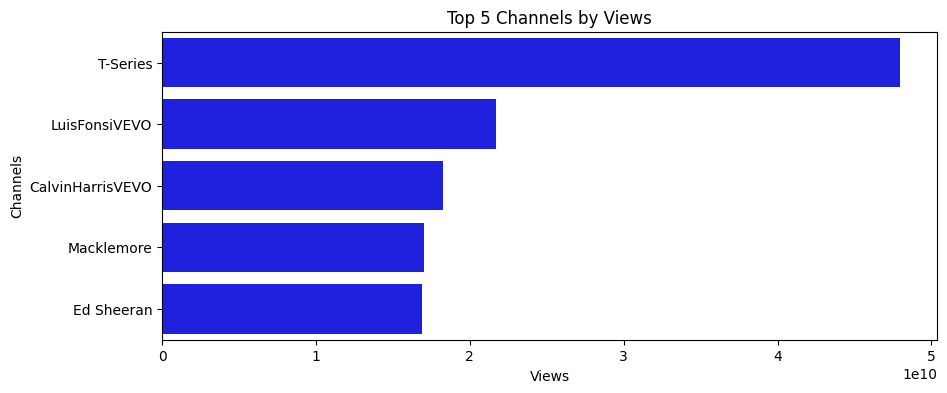

In [101]:
plt.figure(figsize = (10,4))
sns.barplot(x = 'Views', y = 'Channel', data = yt_views, color = 'blue' )
plt.title('Top 5 Channels by Views')
plt.xlabel('Views')
plt.ylabel('Channels');

### 6. Show the top most Track based on views

In [104]:
data.sort_values(by = 'Views', ascending = False).head(1)

,Artist,Track,Album,Album_type,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,...,Duration_ms,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
1147,Luis Fonsi,Despacito,VIDA,album,0.655,0.797,2.0,-4.787,0.153,0.198,...,229360.0,Luis Fonsi - Despacito ft. Daddy Yankee,LuisFonsiVEVO,8.079649e+09,50788652.0,4252791.0,“Despacito” disponible ya en todas las platafo...,True,True,1.506598e+09


### 7. Which toop 7 Tracks have highest Like to Views ratio?

In [106]:
track_lv = data[['Track', 'Views', 'Likes']]
track_lv

,Track,Views,Likes
0,Feel Good Inc.,693555221.0,6220896.0
1,Rhinestone Eyes,72011645.0,1079128.0
2,New Gold (feat. Tame Impala and Bootie Brown),8435055.0,282142.0
3,On Melancholy Hill,211754952.0,1788577.0
4,Clint Eastwood,618480958.0,6197318.0
...,...,...,...
20713,JUST DANCE HARDSTYLE,71678.0,1113.0
20714,SET FIRE TO THE RAIN HARDSTYLE,164741.0,2019.0
20715,OUTSIDE HARDSTYLE SPED UP,35646.0,329.0
20716,ONLY GIRL HARDSTYLE,6533.0,88.0


In [111]:
track_lv['LV_Ratio'] = track_lv['Likes']/track_lv['Views']*100

C:\Users\hmmuz\AppData\Local\Temp\ipykernel_22064\3962420856.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  track_lv['LV_Ratio'] = track_lv['Likes']/track_lv['Views']*100


In [112]:
track_lv

,Track,Views,Likes,LV_Ratio
0,Feel Good Inc.,693555221.0,6220896.0,0.896958
1,Rhinestone Eyes,72011645.0,1079128.0,1.498547
2,New Gold (feat. Tame Impala and Bootie Brown),8435055.0,282142.0,3.344874
3,On Melancholy Hill,211754952.0,1788577.0,0.844645
4,Clint Eastwood,618480958.0,6197318.0,1.002022
...,...,...,...,...
20713,JUST DANCE HARDSTYLE,71678.0,1113.0,1.552778
20714,SET FIRE TO THE RAIN HARDSTYLE,164741.0,2019.0,1.225560
20715,OUTSIDE HARDSTYLE SPED UP,35646.0,329.0,0.922965
20716,ONLY GIRL HARDSTYLE,6533.0,88.0,1.347008


In [113]:
track_lv.sort_values(by = 'LV_Ratio', ascending = False).head(7)

,Track,Views,Likes,LV_Ratio
19968,Intro,954081.0,237761.0,24.920421
19969,Safety Zone,1952637.0,453910.0,23.246000
19967,Future,1180522.0,250116.0,21.186899
19971,Pandora's Box,1265231.0,253702.0,20.051832
16297,My Universe - Galantis Remix,2067753.0,371437.0,17.963316
15065,Burn It (feat. MAX),1054438.0,188244.0,17.852543
8105,No.2 (with parkjiyoon),2050047.0,346440.0,16.899125


### 8. What is the Correlatiion between Views, Likes, Comments and Stream?

In [115]:
df_vlcs = data[['Views', 'Likes', 'Comments', 'Stream']]
df_vlcs

,Views,Likes,Comments,Stream
0,693555221.0,6220896.0,169907.0,1.040235e+09
1,72011645.0,1079128.0,31003.0,3.100837e+08
2,8435055.0,282142.0,7399.0,6.306347e+07
3,211754952.0,1788577.0,55229.0,4.346636e+08
4,618480958.0,6197318.0,155930.0,6.172597e+08
...,...,...,...,...
20713,71678.0,1113.0,0.0,9.227144e+06
20714,164741.0,2019.0,0.0,1.089818e+07
20715,35646.0,329.0,0.0,6.226110e+06
20716,6533.0,88.0,0.0,6.873961e+06


In [116]:
df_vlcs.corr()

,Views,Likes,Comments,Stream
Views,1.000000,0.891695,0.431077,0.603510
Likes,0.891695,1.000000,0.631035,0.655808
Comments,0.431077,0.631035,1.000000,0.267833
Stream,0.603510,0.655808,0.267833,1.000000


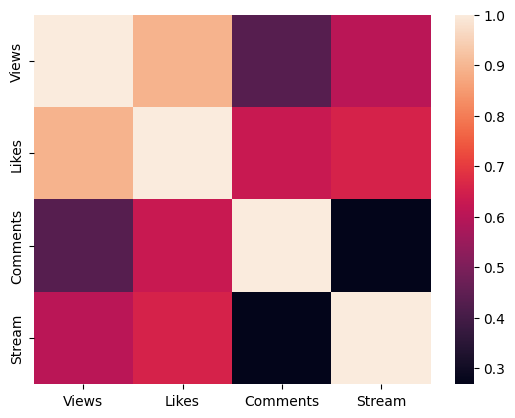

In [118]:
sns.heatmap(df_vlcs.corr());